In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

In [4]:
df = pd.read_csv("../data/traffic.csv")
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [5]:
print(df.shape)
print(df.columns.tolist())
df.info()

(48120, 4)
['DateTime', 'Junction', 'Vehicles', 'ID']
<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 1.5 MB


In [6]:
df["DateTime"] = pd.to_datetime(df["DateTime"], dayfirst=True, errors="coerce")
print(df["DateTime"].isna().sum())
df.head()

29112


,DateTime,Junction,Vehicles,ID
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041


In [7]:
df = df.sort_values(["Junction", "DateTime"]).reset_index(drop=True)
df.head(10)

,DateTime,Junction,Vehicles,ID
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041
5,2015-01-11 05:00:00,1,6,20151101051
6,2015-01-11 06:00:00,1,9,20151101061
7,2015-01-11 07:00:00,1,8,20151101071
8,2015-01-11 08:00:00,1,11,20151101081
9,2015-01-11 09:00:00,1,12,20151101091


In [8]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique junctions:")
print(df["Junction"].unique())

Missing values:
DateTime    29112
Junction        0
Vehicles        0
ID              0
dtype: int64

Duplicate rows: 0

Unique junctions:
[1 2 3 4]


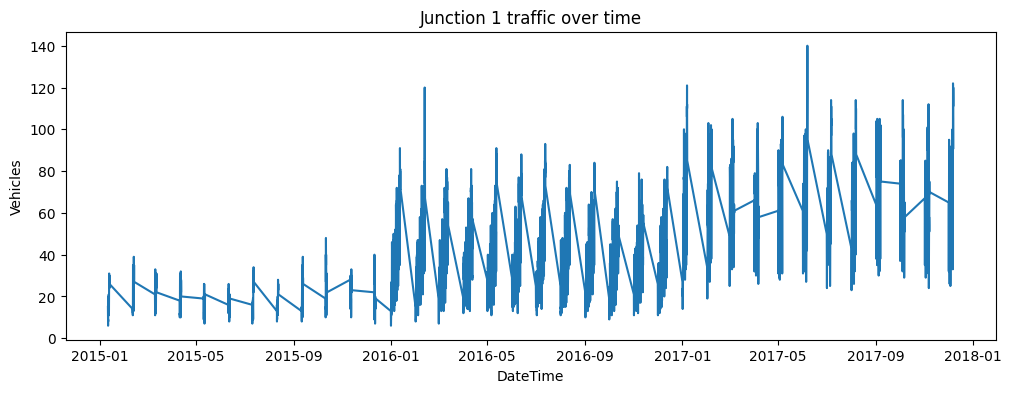

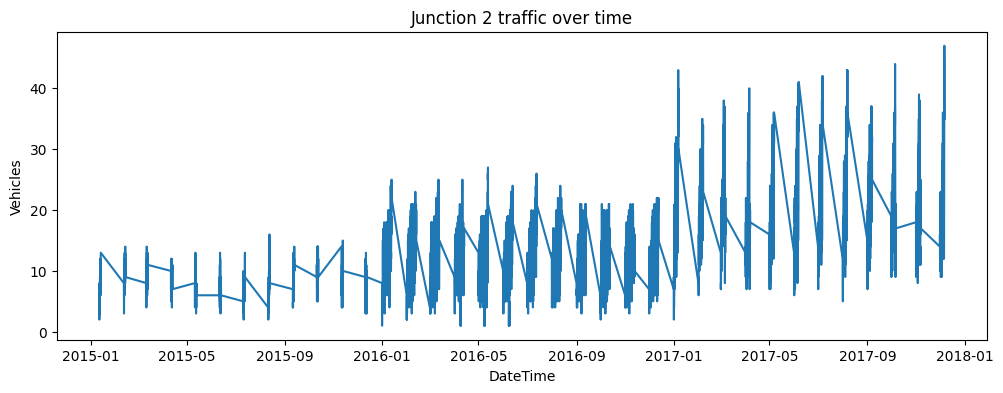

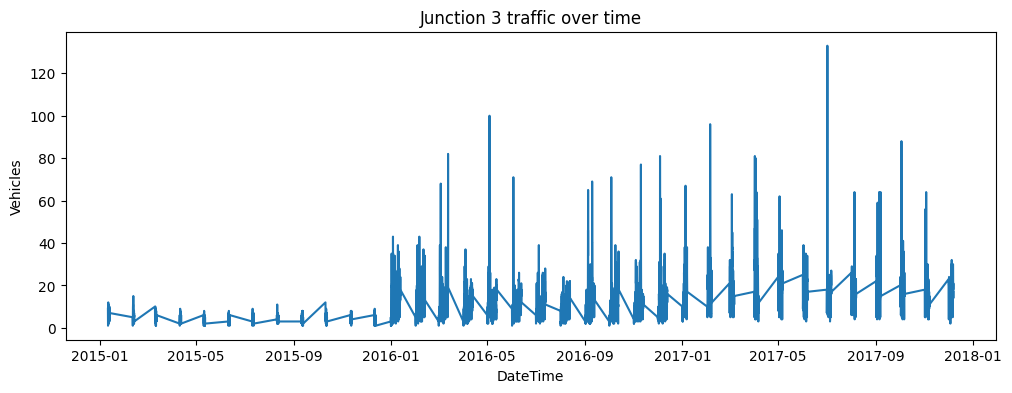

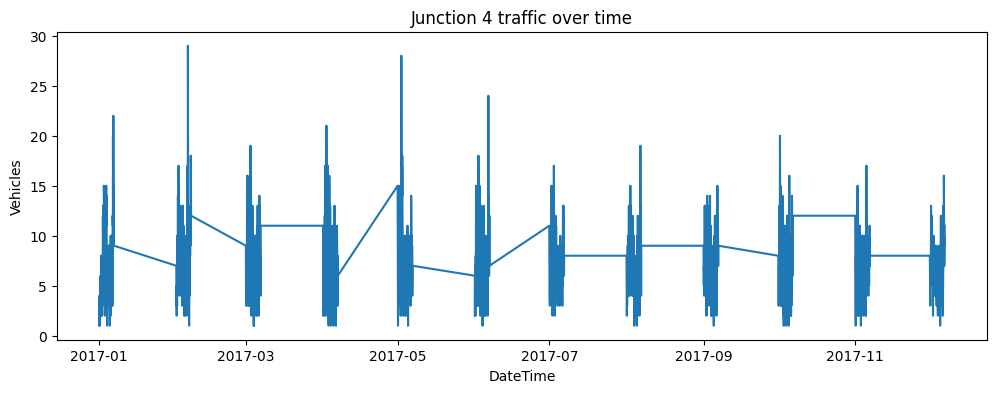

In [9]:
for j in sorted(df["Junction"].unique()):
    temp = df[df["Junction"] == j]
    plt.figure(figsize=(12, 4))
    plt.plot(temp["DateTime"], temp["Vehicles"])
    plt.title(f"Junction {j} traffic over time")
    plt.xlabel("DateTime")
    plt.ylabel("Vehicles")
    plt.show()

In [10]:
df["target"] = df.groupby("Junction")["Vehicles"].shift(-1)
df[["DateTime", "Junction", "Vehicles", "target"]].head(10)

,DateTime,Junction,Vehicles,target
0,2015-01-11 00:00:00,1,15,13.0
1,2015-01-11 01:00:00,1,13,10.0
2,2015-01-11 02:00:00,1,10,7.0
3,2015-01-11 03:00:00,1,7,9.0
4,2015-01-11 04:00:00,1,9,6.0
5,2015-01-11 05:00:00,1,6,9.0
6,2015-01-11 06:00:00,1,9,8.0
7,2015-01-11 07:00:00,1,8,11.0
8,2015-01-11 08:00:00,1,11,12.0
9,2015-01-11 09:00:00,1,12,15.0


In [11]:
df["hour"] = df["DateTime"].dt.hour
df["day_of_week"] = df["DateTime"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

for lag in [1, 2, 3, 6, 24]:
    df[f"lag_{lag}"] = df.groupby("Junction")["Vehicles"].shift(lag)

df["rolling_mean_3"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(1)
      .rolling(3)
      .mean()
)

df["rolling_mean_24"] = (
    df.groupby("Junction")["Vehicles"]
      .shift(1)
      .rolling(24)
      .mean()
)

In [12]:
model_df = df.dropna().copy()
print(model_df.shape)
model_df.head()

(18912, 15)


,DateTime,Junction,Vehicles,ID,target,hour,day_of_week,is_weekend,lag_1,lag_2,lag_3,lag_6,lag_24,rolling_mean_3,rolling_mean_24
24,2015-01-12 00:00:00,1,21,20151201001,20.0,0.0,0.0,0,15.0,20.0,19.0,17.0,15.0,18.000000,13.625000
25,2015-01-12 01:00:00,1,20,20151201011,18.0,1.0,0.0,0,21.0,15.0,20.0,20.0,13.0,18.666667,13.875000
26,2015-01-12 02:00:00,1,18,20151201021,13.0,2.0,0.0,0,20.0,21.0,15.0,17.0,10.0,18.666667,14.166667
27,2015-01-12 03:00:00,1,13,20151201031,14.0,3.0,0.0,0,18.0,20.0,21.0,19.0,7.0,19.666667,14.500000
28,2015-01-12 04:00:00,1,14,20151201041,11.0,4.0,0.0,0,13.0,18.0,20.0,20.0,9.0,17.000000,14.750000


In [13]:
model_df["baseline_pred"] = model_df["Vehicles"]

baseline_mae = np.mean(np.abs(model_df["target"] - model_df["baseline_pred"]))
baseline_rmse = np.sqrt(np.mean((model_df["target"] - model_df["baseline_pred"]) ** 2))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 3.3762161590524533
Baseline RMSE: 5.176633650936366


In [14]:
feature_cols = [
    "Junction",
    "Vehicles",
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_24",
    "rolling_mean_3",
    "rolling_mean_24",
]

X = model_df[feature_cols]
y = model_df["target"]

split_idx = int(len(model_df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(15129, 12) (3783, 12)


In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = np.mean(np.abs(y_test - preds))
rmse = np.sqrt(np.mean((y_test - preds) ** 2))

print("Model MAE:", mae)
print("Model RMSE:", rmse)

Model MAE: 2.670930198535319
Model RMSE: 4.7316072219627765


In [16]:
baseline_test = X_test["Vehicles"]

baseline_test_mae = np.mean(np.abs(y_test - baseline_test))
baseline_test_rmse = np.sqrt(np.mean((y_test - baseline_test) ** 2))

print("Baseline test MAE:", baseline_test_mae)
print("Baseline test RMSE:", baseline_test_rmse)
print("Model test MAE:", mae)
print("Model test RMSE:", rmse)

Baseline test MAE: 3.233148295003965
Baseline test RMSE: 5.3765677560425
Model test MAE: 2.670930198535319
Model test RMSE: 4.7316072219627765


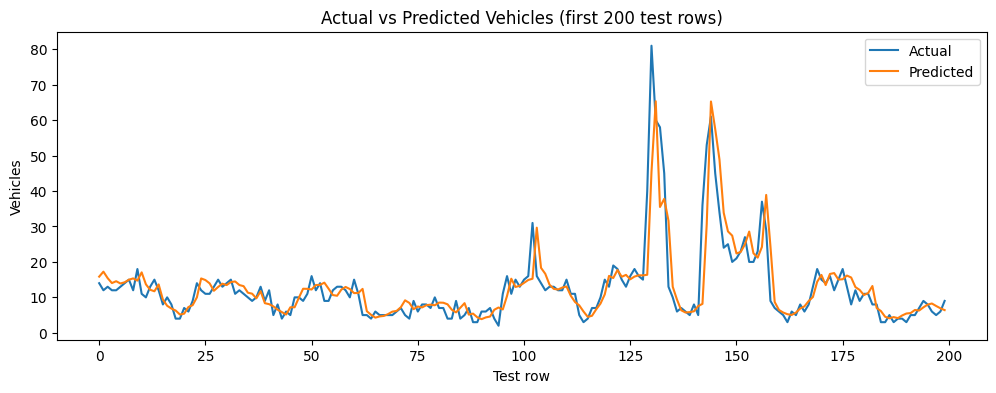

In [17]:
plot_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": preds
}).reset_index(drop=True)

plt.figure(figsize=(12, 4))
plt.plot(plot_df["actual"].iloc[:200].values, label="Actual")
plt.plot(plot_df["predicted"].iloc[:200].values, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Vehicles (first 200 test rows)")
plt.xlabel("Test row")
plt.ylabel("Vehicles")
plt.show()